# Portion Estimation — Food-101
## Pipeline: CNN → YOLO → SAM-b → Ratio Features → S/M/L
```

In [40]:
# YOLO + timm
!pip install -q ultralytics timm

In [41]:
import os, cv2, json, random
import numpy as np
import pandas as pd
from ultralytics import YOLOWorld
import torch
import torch.nn as nn
import timm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from torchvision import transforms
from PIL import Image
from ultralytics import SAM
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)

# Paths
IMAGE_DIR  = Path('/kaggle/input/datasets/minhquang2701/food101-15cla')
CNN_CKPT   = '/kaggle/input/models/minhquang2701/model1/keras/default/1/best_model.keras'
OUTPUT_DIR = Path('/kaggle/working/portion_output')
OUTPUT_DIR.mkdir(exist_ok=True)

# Classes
CLASSES = [
    'pizza', 'hamburger', 'french_fries', 'ice_cream', 'chocolate_cake',
    'sushi', 'ramen', 'fried_rice', 'omelette', 'pancakes',
    'hot_dog', 'grilled_salmon', 'caesar_salad', 'donuts', 'dumplings',
]

# Portion thresholds
THRESHOLDS    = {'small': 0.28, 'large': 0.55}
COLOR_MAP    = {'Small':'#3498db','Medium':'#f39c12','Large':'#e74c3c'}
SEED         = 42
N_LABEL_PER_CLASS = 10   # 10 ảnh/class = 150 ảnh tổng
N_SAMPLE_PER_CLASS = 100

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

print(tf.__version__)
print(keras.__version__)

Device: cuda
2.19.0
3.10.0


In [42]:
from tensorflow.keras import mixed_precision, layers

mixed_precision.set_global_policy('mixed_float16')
print('Policy:', mixed_precision.global_policy())

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# 3. Rebuild kiến trúc ĐÚNG như training
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights=None,              
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs  = layers.Input(shape=(224, 224, 3))
x       = data_augmentation(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.2)(x)

NUM_CLASSES = 15
outputs = layers.Dense(
    NUM_CLASSES,
    activation='softmax',
    dtype=tf.float32            # explicit float32
)(x)

cnn_model = tf.keras.Model(inputs, outputs)

cnn_model(tf.zeros((1, 224, 224, 3)), training=False)

# Load weights từ .keras file, bỏ qua config, chỉ lấy weights
cnn_model.load_weights(CNN_CKPT)
cnn_model.trainable = False

print('✓ CNN loaded via load_weights')
print('  Input :', cnn_model.input_shape)
print('  Output:', cnn_model.output_shape)

# Yolo
yolo_model = YOLOWorld('yolov8x-worldv2.pt')
# Set classes = đúng 15 class của dataset
yolo_model.set_classes(CLASSES)
print('✓ YOLO world loaded')

# Sam
sam_model = SAM('sam_b.pt')
sam_model.to(DEVICE)
print('✓ SAM-b loaded on', DEVICE)

Policy: <DTypePolicy "mixed_float16">
✓ CNN loaded via load_weights
  Input : (None, 224, 224, 3)
  Output: (None, 15)
✓ YOLO world loaded
✓ SAM-b loaded on cuda


In [43]:
# TIỀN XỬ LÝ
def preprocess_image(img_bgr, size=256):
    return cv2.resize(img_bgr, (size, size), interpolation=cv2.INTER_LINEAR)

def preprocess_for_cnn(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_224 = cv2.resize(img_rgb, (224, 224), interpolation=cv2.INTER_LINEAR)
    # float32, range [0,255] — EfficientNetB0 tự normalize nội bộ
    return np.expand_dims(img_224.astype(np.float32), axis=0)

In [44]:
# CNN CLASSIFY
# Output: tên class + confidence
def cnn_classify(img_bgr):
    x     = preprocess_for_cnn(img_bgr)
    preds = cnn_model.predict(x, verbose=0)[0]   # (15,)
    idx   = int(np.argmax(preds))
    return CLASSES[idx], float(preds[idx])

test_img = cv2.imread(
    str(
        sorted(
            (IMAGE_DIR / 'pizza').glob('*.jpg')
        )[0]
    )
)

cls, conf = cnn_classify(test_img)

print(
    f'CNN test → class: {cls}  conf: {conf:.1%}'
)

CNN test → class: pizza  conf: 99.9%


In [45]:
# YOLO DETECT FOOD REGION
def yolo_detect(img_bgr, conf_thr=0.25):
    h, w    = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    results = yolo_model(img_rgb, conf=conf_thr, verbose=False)
    boxes   = results[0].boxes

    if boxes is not None and len(boxes) > 0:
        confs = boxes.conf.cpu().numpy()
        xyxy  = boxes.xyxy.cpu().numpy()
        best  = int(np.argmax(confs))
        return xyxy[best].tolist(), 'world_detect'

    # Fallback
    m = 0.15
    return [int(w*m),int(h*m),int(w*(1-m)),int(h*(1-m))], 'center_fallback'


def expand_bbox(bbox, shape, margin=0.05):
    h, w = shape[:2]
    x1,y1,x2,y2 = bbox
    dx,dy = (x2-x1)*margin, (y2-y1)*margin
    return [max(0,int(x1-dx)), max(0,int(y1-dy)),
            min(w-1,int(x2+dx)), min(h-1,int(y2+dy))]


In [46]:
# BƯỚC 3 — SAM-b
def sam_refine(img_bgr: np.ndarray, bbox: list) -> np.ndarray:
    """
    Input : ảnh BGR + bbox [x1,y1,x2,y2]
    Output: binary mask uint8 (0/255)
    """
    h, w    = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    try:
        results      = sam_model(img_rgb, bboxes=[bbox], verbose=False)
        masks_tensor = results[0].masks

        if masks_tensor is not None and len(masks_tensor) > 0:
            masks_np = masks_tensor.data.cpu().numpy()  # (N, H, W)
            # Chọn mask có diện tích lớn nhất
            best  = masks_np[int(np.argmax([m.sum() for m in masks_np]))]
            binary = (best * 255).astype(np.uint8)
        else:
            # Fallback: vẽ bbox thành mask
            binary = np.zeros((h, w), dtype=np.uint8)
            x1,y1,x2,y2 = [int(v) for v in bbox]
            binary[y1:y2, x1:x2] = 255

    except Exception as e:
        print(f'  [SAM warning] {e}')
        binary = np.zeros((h, w), dtype=np.uint8)
        x1,y1,x2,y2 = [int(v) for v in bbox]
        binary[y1:y2, x1:x2] = 255

    if binary.shape != (h, w):
        binary = cv2.resize(binary, (w, h),
                            interpolation=cv2.INTER_NEAREST)
    return binary

In [47]:
# MASK CLEANUP
def mask_cleanup(mask):
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE,
                            cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(15,15)))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,
                            cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5)))
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    if n > 1:
        lg   = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        mask = np.where(labels==lg, np.uint8(255), np.uint8(0))
    return mask


In [48]:
# GEOMETRY FEATURE EXTRACTION
# 5 ratio từ mask, tất cả ∈ [0,1]
def extract_ratio_features(img_bgr: np.ndarray,
                            mask: np.ndarray,
                            food_class: str = '') -> dict:
    h, w         = img_bgr.shape[:2]
    total_pixels = h * w
    fg_pixels    = int(mask.sum() // 255)

    feats = {'food_class': food_class,
             'total_pixels': total_pixels,
             'fg_pixels': fg_pixels}

    # R1: diện tích thức ăn / tổng ảnh
    feats['R1_area_ratio'] = round(fg_pixels / total_pixels
                                   if total_pixels > 0 else 0.0, 4)

    # R2: diện tích thức ăn / diện tích bounding box
    # R3: compactness = 4π·A / P²  (1=tròn hoàn hảo, 0=loằng ngoằng)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        lg = max(contours, key=cv2.contourArea)
        x, y, bw, bh = cv2.boundingRect(lg)
        feats['R2_bbox_fill']   = round(
            min(fg_pixels / (bw*bh), 1.0) if bw*bh > 0 else 0.0, 4)
        perim = cv2.arcLength(lg, True)
        feats['R3_compactness'] = round(
            min(4*np.pi*cv2.contourArea(lg)/(perim**2), 1.0)
            if perim > 0 else 0.0, 4)
        feats['_bbox_contour']  = (x, y, bw, bh)
    else:
        feats['R2_bbox_fill']   = 0.0
        feats['R3_compactness'] = 0.0
        feats['_bbox_contour']  = (0, 0, w, h)

    # R4: độ bão hòa màu trung bình trong foreground
    hsv     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    fg_bool = mask > 0
    feats['R4_saturation'] = round(
        float(hsv[:,:,1][fg_bool].mean()) / 255.0
        if fg_bool.any() else 0.0, 4)

    # R5: mật độ cạnh Canny trong foreground
    edges = cv2.Canny(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), 50, 150)
    feats['R5_edge_density'] = round(
        float(cv2.bitwise_and(edges, edges, mask=mask).sum()//255)
        / fg_pixels if fg_pixels > 0 else 0.0, 4)

    return feats

In [49]:
# CLASS-AWARE SCORING
# Trọng số 5 ratio
WEIGHTS = {
    'R1_area_ratio' : 0.50,   # tín hiệu chính
    'R2_bbox_fill'  : 0.25,   # mật độ trong vùng
    'R3_compactness': 0.05,   # hình dạng
    'R4_saturation' : 0.10,   # màu sắc
    'R5_edge_density': 0.10,  # texture
}

# Per-class offset: hiệu chỉnh ngưỡng theo đặc thù từng class
# Giá trị + → nâng ngưỡng (class hay bị ước lượng quá cao)
# Giá trị - → hạ ngưỡng  (class hay bị ước lượng quá thấp)
CLASS_OFFSET = {
    'ramen'        :  0.08,  # tô ramen thường chụp gần, chiếm nhiều frame
    'pizza'        :  0.06,  # pizza nguyên chiếc thường chiếm gần hết ảnh
    'fried_rice'   :  0.05,  # bát cơm rang thường chụp từ trên
    'pancakes'     :  0.04,  # chồng pancakes trông nhiều hơn thực tế
    'caesar_salad' : -0.05,  # salad thưa, trông ít hơn thực tế
    'sushi'        : -0.03,  # sushi sắp hàng thường chiếm ít diện tích
    'dumplings'    : -0.03,  # dumplings nhỏ gọn
}


def compute_weighted_score(feats: dict) -> float:
    return round(sum(WEIGHTS[k] * feats.get(k, 0.0)
                     for k in WEIGHTS), 4)


def classify_portion(score: float, food_class: str = '') -> str:
    offset  = CLASS_OFFSET.get(food_class, 0.0)
    t_s = THRESHOLDS['small'] + offset
    t_l = THRESHOLDS['large'] + offset
    if score < t_s: return 'Small'
    if score > t_l: return 'Large'
    return 'Medium'

In [50]:
# FULL PIPELINE — 1 ảnh
def run_pipeline(img_bgr: np.ndarray,
                 food_class_override: str = None) -> dict:
    # ── 0. Preprocess ──
    pre = preprocess_image(img_bgr, size=512)

    # ── 1. CNN classify ──
    food_class, cnn_conf = cnn_classify(pre)
    if food_class_override:
        food_class = food_class_override   # dùng khi biết nhãn thật

    # ── 2. YOLO detect ──
    raw_bbox, yolo_src = yolo_detect(pre)
    bbox = expand_bbox(raw_bbox, pre.shape, margin=0.05)

    # ── 3. SAM refine ──
    mask_raw = sam_refine(pre, bbox)

    # ── 4. Mask cleanup ──
    mask = mask_cleanup(mask_raw)

    # ── 5. Ratio features ──
    feats = extract_ratio_features(pre, mask, food_class)

    # ── 6. Class-aware scoring ──
    score   = compute_weighted_score(feats)
    portion = classify_portion(score, food_class)

    return {
        **feats,
        'cnn_class'      : food_class,
        'cnn_conf'       : round(cnn_conf, 4),
        'yolo_bbox'      : bbox,
        'yolo_source'    : yolo_src,
        'weighted_score' : score,
        'portion_label'  : portion,
        # internal — không lưu CSV
        '_pre'           : pre,
        '_mask_raw'      : mask_raw,
        '_mask'          : mask,
    }

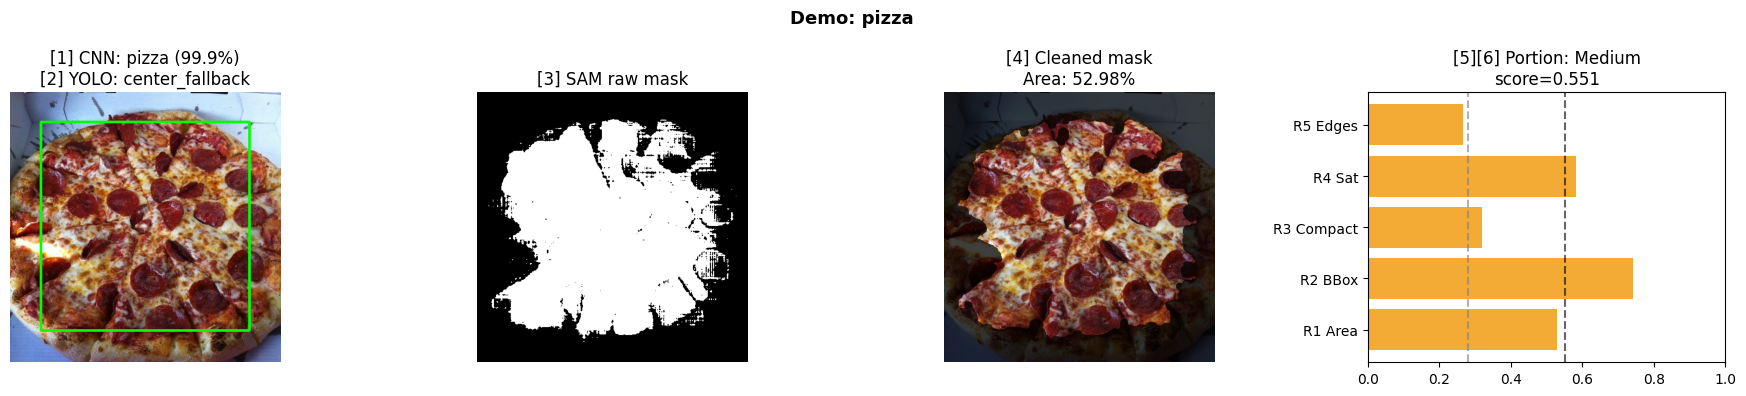

In [51]:
# DEMO — kiểm tra pipeline trên 1 ảnh trước khi batch
def visualize_pipeline(result: dict, title: str = '') -> None:
    pre       = result['_pre']
    mask_raw  = result['_mask_raw']
    mask      = result['_mask']
    bbox      = result['yolo_bbox']
    portion   = result['portion_label']
    score     = result['weighted_score']

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    # Panel 1: original + YOLO bbox
    vis = pre.copy()
    x1,y1,x2,y2 = [int(v) for v in bbox]
    cv2.rectangle(vis, (x1,y1), (x2,y2), (0,255,0), 3)
    axes[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[0].set_title(
        f'[1] CNN: {result["cnn_class"]} ({result["cnn_conf"]:.1%})\n'
        f'[2] YOLO: {result["yolo_source"]}')
    axes[0].axis('off')

    # Panel 2: SAM raw mask
    axes[1].imshow(mask_raw, cmap='gray')
    axes[1].set_title('[3] SAM raw mask')
    axes[1].axis('off')

    # Panel 3: cleaned mask overlay
    overlay = pre.copy()
    overlay[mask == 0] = (overlay[mask == 0] * 0.25).astype(np.uint8)
    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[2].set_title(
        f'[4] Cleaned mask\nArea: {result["R1_area_ratio"]:.2%}')
    axes[2].axis('off')

    # Panel 4: ratio bars
    names  = ['R1 Area','R2 BBox','R3 Compact','R4 Sat','R5 Edges']
    values = [result['R1_area_ratio'], result['R2_bbox_fill'],
              result['R3_compactness'], result['R4_saturation'],
              result['R5_edge_density']]
    color  = COLOR_MAP[portion]
    axes[3].barh(names, values, color=color, alpha=0.85)
    axes[3].set_xlim(0, 1)
    axes[3].axvline(THRESHOLDS['small'], color='gray',
                    linestyle='--', alpha=0.6)
    axes[3].axvline(THRESHOLDS['large'], color='black',
                    linestyle='--', alpha=0.6)
    axes[3].set_title(
        f'[5][6] Portion: {portion}\nscore={score:.3f}')

    fig.suptitle(title or result['cnn_class'],
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'demo_pipeline.png',
                dpi=150, bbox_inches='tight')
    plt.show()


# Chạy thử trên 1 ảnh pizza
demo_path = sorted((IMAGE_DIR / 'pizza').glob('*.jpg'))[0]
demo_bgr  = cv2.imread(str(demo_path))
demo_res  = run_pipeline(demo_bgr)
visualize_pipeline(demo_res, title='Demo: pizza')

In [52]:
# BATCH RUN — xem phân bố prediction tổng thể
def collect_paths(classes, n, seed=42):
    random.seed(seed)
    recs = []
    for cls in classes:
        imgs = sorted((IMAGE_DIR / cls).glob('*.jpg'))
        recs += [{'path': str(p), 'food_class': cls}
                 for p in random.sample(imgs, min(n, len(imgs)))]
    return recs


def batch_run(classes, n=N_SAMPLE_PER_CLASS):
    recs    = collect_paths(classes, n, SEED)
    results = []
    # yolo_stats = {'food_class':0, 'any_object':0, 'center_fallback':0}
    yolo_stats = {
        'food_class':0,
        'any_object':0,
        'center_fallback':0,
        'world_detect':0
    }

    for rec in tqdm(recs, desc='Batch pipeline'):
        img = cv2.imread(rec['path'])
        if img is None: continue
        r = run_pipeline(img, food_class_override=rec['food_class'])
        yolo_stats[r['yolo_source']] += 1
        results.append({k: v for k, v in r.items()
                        if not k.startswith('_')})

    df = pd.DataFrame(results)
    df.to_csv(OUTPUT_DIR / 'batch_predictions.csv', index=False)

    print(f'\n✓ Đã xử lý {len(df)} ảnh')
    print('\n── YOLO detection source ──')
    for src, cnt in yolo_stats.items():
        print(f'  {src:20s}: {cnt:4d}  ({cnt/len(df):.1%})')
    print('\n── Phân bố portion labels ──')
    print(df['portion_label'].value_counts().to_string())
    print('\n── Phân bố theo class ──')
    print(df.groupby('food_class')['portion_label']
            .value_counts().unstack(fill_value=0).to_string())
    return df


df_batch = batch_run(CLASSES)

Batch pipeline: 100%|██████████| 1500/1500 [17:49<00:00,  1.40it/s]


✓ Đã xử lý 1500 ảnh

── YOLO detection source ──
  food_class          :    0  (0.0%)
  any_object          :    0  (0.0%)
  center_fallback     :  831  (55.4%)
  world_detect        :  669  (44.6%)

── Phân bố portion labels ──
portion_label
Medium    876
Small     524
Large     100

── Phân bố theo class ──
portion_label   Large  Medium  Small
food_class                          
caesar_salad       15      61     24
chocolate_cake      8      66     26
donuts              1      80     19
dumplings           3      57     40
french_fries        6      40     54
fried_rice         13      56     31
grilled_salmon      6      60     34
hamburger           4      58     38
hot_dog             2      63     35
ice_cream           6      61     33
omelette            5      59     36
pancakes            5      46     49
pizza              14      42     44
ramen               9      60     31
sushi               3      67     30


In [53]:
# GÁN NHÃN THỦ CÔNG — 10 ảnh/class = 150 ảnh
#
# Tiêu chí nhất quán:
#   Small  : thức ăn < 1/3 khung hình
#   Medium : thức ăn 1/3 – 2/3 khung hình
#   Large  : thức ăn > 2/3 khung hình hoặc cả đĩa/tô đầy
def interactive_label(recs, save_path):
    results = []
    for i, rec in enumerate(recs):
        img = cv2.imread(rec['path'])
        if img is None: continue
        r    = run_pipeline(img, food_class_override=rec['food_class'])
        pred = r['portion_label']

        fig, axes = plt.subplots(1, 4, figsize=(17, 4))

        # original + bbox
        vis = r['_pre'].copy()
        x1,y1,x2,y2 = [int(v) for v in r['yolo_bbox']]
        cv2.rectangle(vis,(x1,y1),(x2,y2),(0,255,0),3)
        axes[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f'YOLO: {r["yolo_source"]}')
        axes[0].axis('off')

        # cleaned mask
        overlay = r['_pre'].copy()
        overlay[r['_mask']==0] = (overlay[r['_mask']==0]*0.25).astype(np.uint8)
        axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'SAM mask\nArea: {r["R1_area_ratio"]:.2%}')
        axes[1].axis('off')

        # ratio bars
        names  = ['R1 Area','R2 BBox','R3 Compact','R4 Sat','R5 Edges']
        values = [r['R1_area_ratio'], r['R2_bbox_fill'],
                  r['R3_compactness'], r['R4_saturation'],
                  r['R5_edge_density']]
        axes[2].barh(names, values, color=COLOR_MAP[pred], alpha=0.85)
        axes[2].set_xlim(0,1)
        axes[2].set_title(f'System: {pred}\nscore={r["weighted_score"]:.3f}')
        axes[2].axvline(THRESHOLDS['small'],color='gray',linestyle='--')
        axes[2].axvline(THRESHOLDS['large'],color='black',linestyle='--')

        # CNN info
        axes[3].text(0.5, 0.6,
            f'CNN: {r["cnn_class"]}\n({r["cnn_conf"]:.1%})',
            ha='center', va='center', fontsize=13,
            transform=axes[3].transAxes,
            bbox=dict(boxstyle='round', facecolor='#EAF2FB', alpha=0.8))
        axes[3].text(0.5, 0.25,
            f'Score: {r["weighted_score"]:.3f}',
            ha='center', va='center', fontsize=11,
            color=COLOR_MAP[pred], fontweight='bold',
            transform=axes[3].transAxes)
        axes[3].axis('off')

        fig.suptitle(
            f'[{i+1}/{len(recs)}] {rec["food_class"]}',
            fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()

        while True:
            ans = input(
                f'  System: [{pred}] | '
                'Nhãn (S/M/L hoặc Enter đồng ý): '
            ).strip().upper()
            if ans == '':  label = pred; break
            if ans in ('S','M','L'):
                label = {'S':'Small','M':'Medium','L':'Large'}[ans]
                break
            print('  → Chỉ nhập S, M, L hoặc Enter')

        results.append({
            **{k: v for k, v in r.items() if not k.startswith('_')},
            'manual_label': label,
            'path': rec['path'],
        })
        plt.close('all')

    df = pd.DataFrame(results)
    df.to_csv(save_path, index=False)
    print(f'\n✓ Đã lưu {len(df)} nhãn → {save_path}')
    return df


label_csv = OUTPUT_DIR / 'manual_labels.csv'
if not label_csv.exists():
    recs_to_label = collect_paths(CLASSES, N_LABEL_PER_CLASS, SEED)
    df_labeled    = interactive_label(recs_to_label, label_csv)
else:
    print(f'✓ Đã có nhãn: {label_csv}')
    df_labeled = pd.read_csv(label_csv)

✓ Đã có nhãn: /kaggle/working/portion_output/manual_labels.csv


  PORTION ESTIMATION — KẾT QUẢ ĐÁNH GIÁ
  Pipeline : CNN(EfficientNet-B0) → YOLO → SAM-b
  Ảnh      : 150  (10/class)
  Accuracy : 56.0%

              precision    recall  f1-score   support

       Small       0.19      0.53      0.28        17
      Medium       0.70      0.73      0.72        86
       Large       1.00      0.26      0.41        47

    accuracy                           0.56       150
   macro avg       0.63      0.51      0.47       150
weighted avg       0.74      0.56      0.57       150



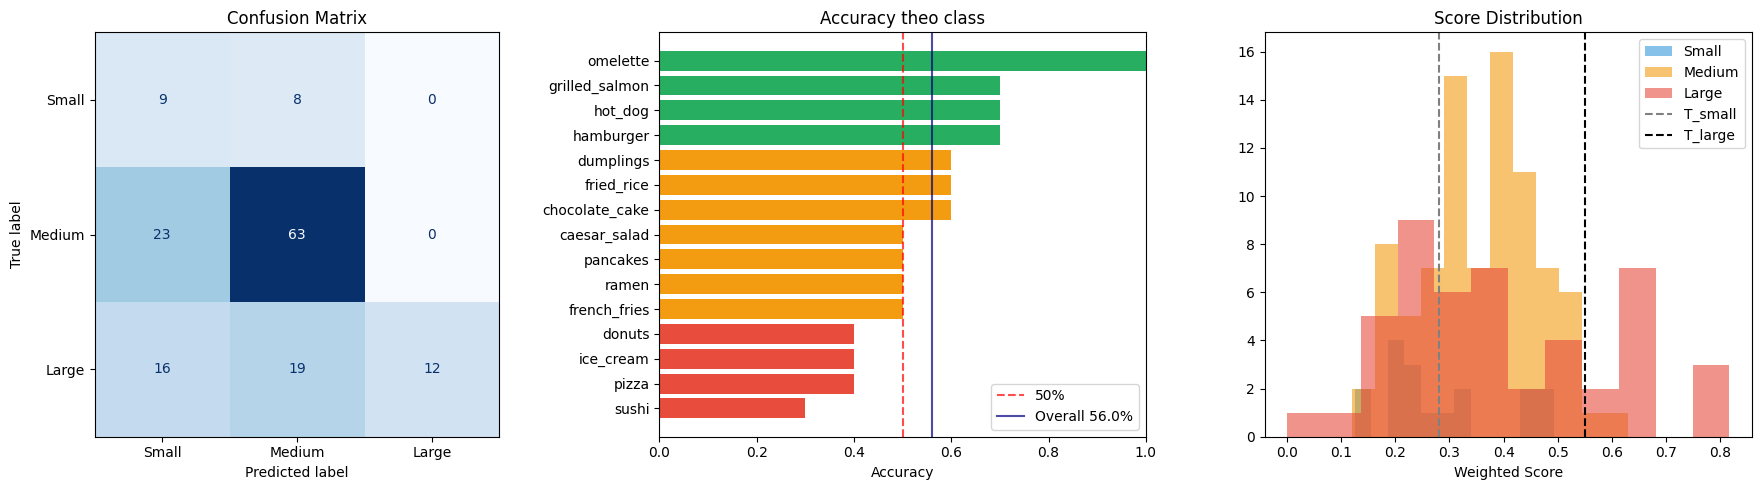


── Nhầm lẫn phổ biến ──
manual_label portion_label  count
      Medium         Small     23
       Large        Medium     19
       Large         Small     16
       Small        Medium      8

── YOLO detection source ──
yolo_source
world_detect       76
center_fallback    74


In [54]:
# ĐÁNH GIÁ ĐỊNH LƯỢNG
def evaluate(df):
    y_true = df['manual_label'].tolist()
    y_pred = df['portion_label'].tolist()
    labels = ['Small','Medium','Large']
    acc    = sum(t==p for t,p in zip(y_true,y_pred)) / len(y_true)

    print('='*55)
    print('  PORTION ESTIMATION — KẾT QUẢ ĐÁNH GIÁ')
    print('='*55)
    print(f'  Pipeline : CNN(EfficientNet-B0) → YOLO → SAM-b')
    print(f'  Ảnh      : {len(df)}  ({N_LABEL_PER_CLASS}/class)')
    print(f'  Accuracy : {acc:.1%}')
    print()
    print(classification_report(y_true, y_pred,
                                labels=labels, zero_division=0))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(
        ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title('Confusion Matrix')

    # Per-class accuracy
    cls_acc = {}
    for cls in CLASSES:
        sub = df[df['food_class']==cls]
        if len(sub): cls_acc[cls] = (sub['manual_label']==sub['portion_label']).mean()
    s_cls = sorted(cls_acc, key=cls_acc.get)
    colors = ['#e74c3c' if cls_acc[c]<0.5 else
              '#f39c12' if cls_acc[c]<0.7 else
              '#27ae60' for c in s_cls]
    axes[1].barh(s_cls, [cls_acc[c] for c in s_cls], color=colors)
    axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='50%')
    axes[1].axvline(acc, color='navy', linestyle='-', alpha=0.7,
                   label=f'Overall {acc:.1%}')
    axes[1].set_xlim(0,1); axes[1].set_xlabel('Accuracy')
    axes[1].set_title('Accuracy theo class'); axes[1].legend()

    # Score distribution
    for lbl in ['Small','Medium','Large']:
        sub = df[df['manual_label']==lbl]['weighted_score']
        axes[2].hist(sub, bins=12, alpha=0.6,
                     label=lbl, color=COLOR_MAP[lbl])
    axes[2].axvline(THRESHOLDS['small'],color='gray',
                    linestyle='--', label='T_small')
    axes[2].axvline(THRESHOLDS['large'],color='black',
                    linestyle='--', label='T_large')
    axes[2].set_xlabel('Weighted Score')
    axes[2].set_title('Score Distribution')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Lỗi thường gặp
    errors = df[df['manual_label']!=df['portion_label']]
    print('\n── Nhầm lẫn phổ biến ──')
    print(errors.groupby(['manual_label','portion_label'])
                .size().reset_index(name='count')
                .sort_values('count',ascending=False)
                .to_string(index=False))

    # YOLO source stats
    if 'yolo_source' in df.columns:
        print('\n── YOLO detection source ──')
        print(df['yolo_source'].value_counts().to_string())


evaluate(df_labeled)

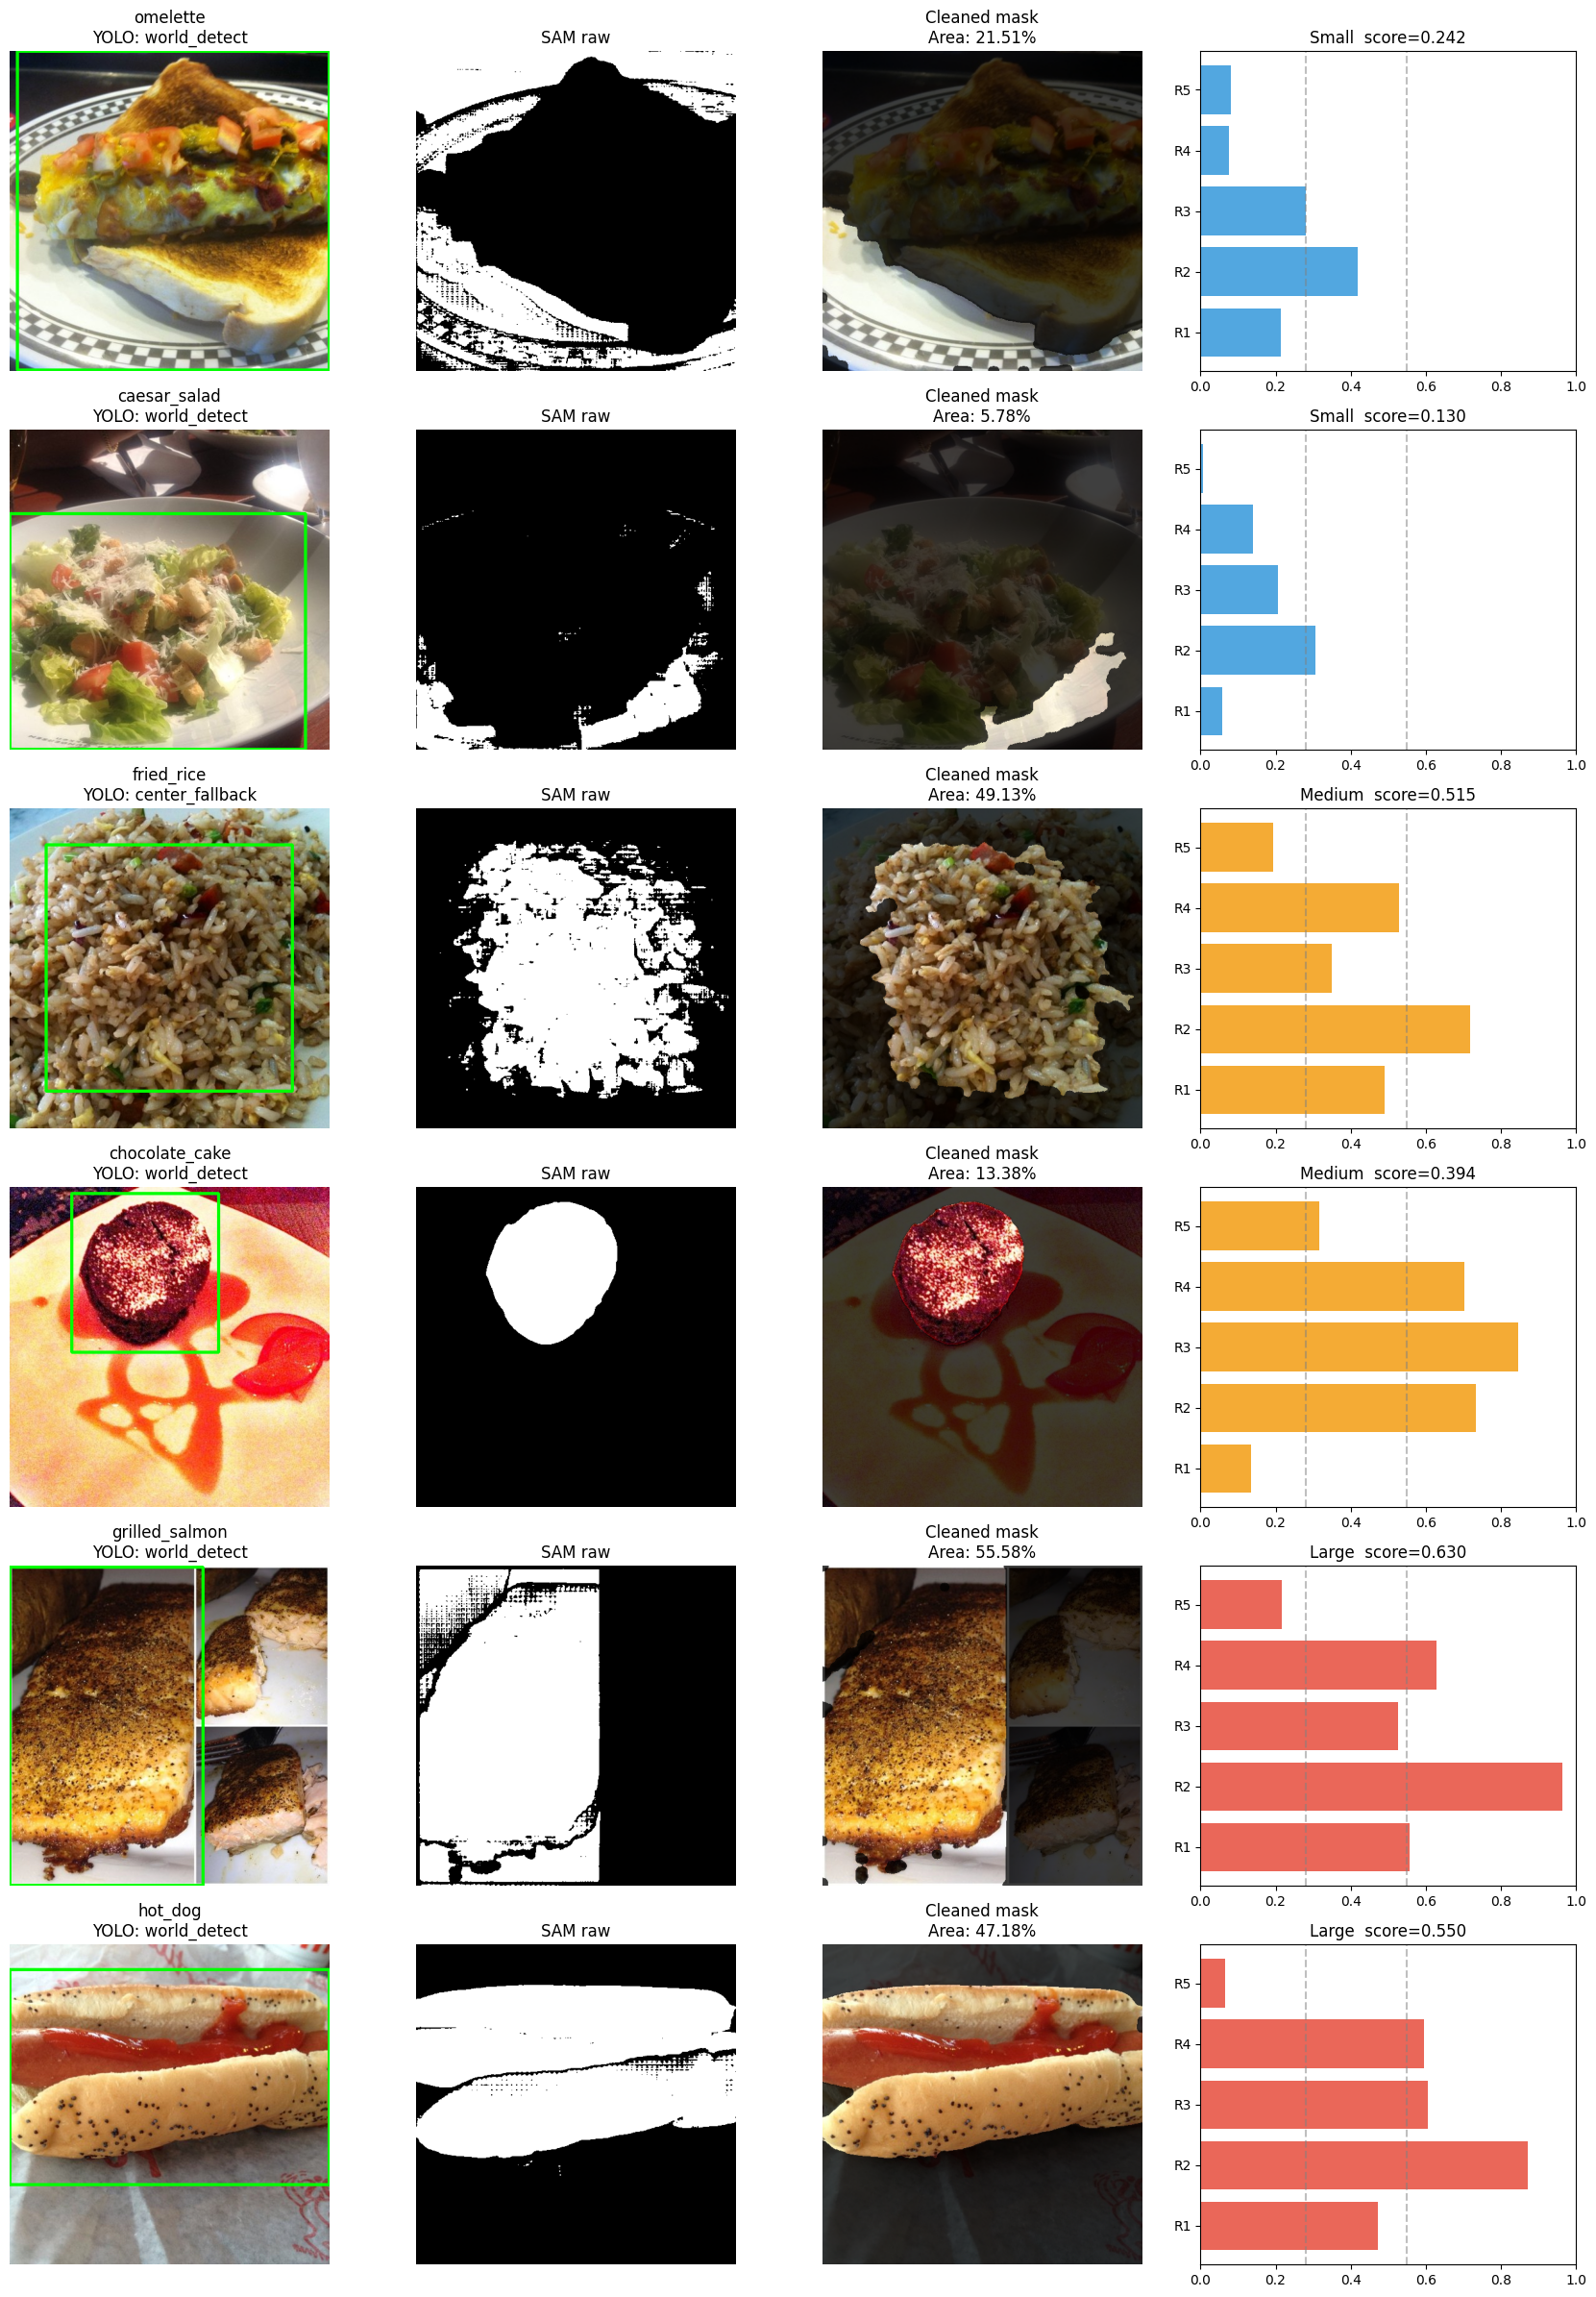

/tmp/ipykernel_57/3931579052.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = ax.boxplot(data, labels=['S','M','L'], patch_artist=True)
/tmp/ipykernel_57/3931579052.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = ax.boxplot(data, labels=['S','M','L'], patch_artist=True)
/tmp/ipykernel_57/3931579052.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = ax.boxplot(data, labels=['S','M','L'], patch_artist=True)
/tmp/ipykernel_57/3931579052.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will

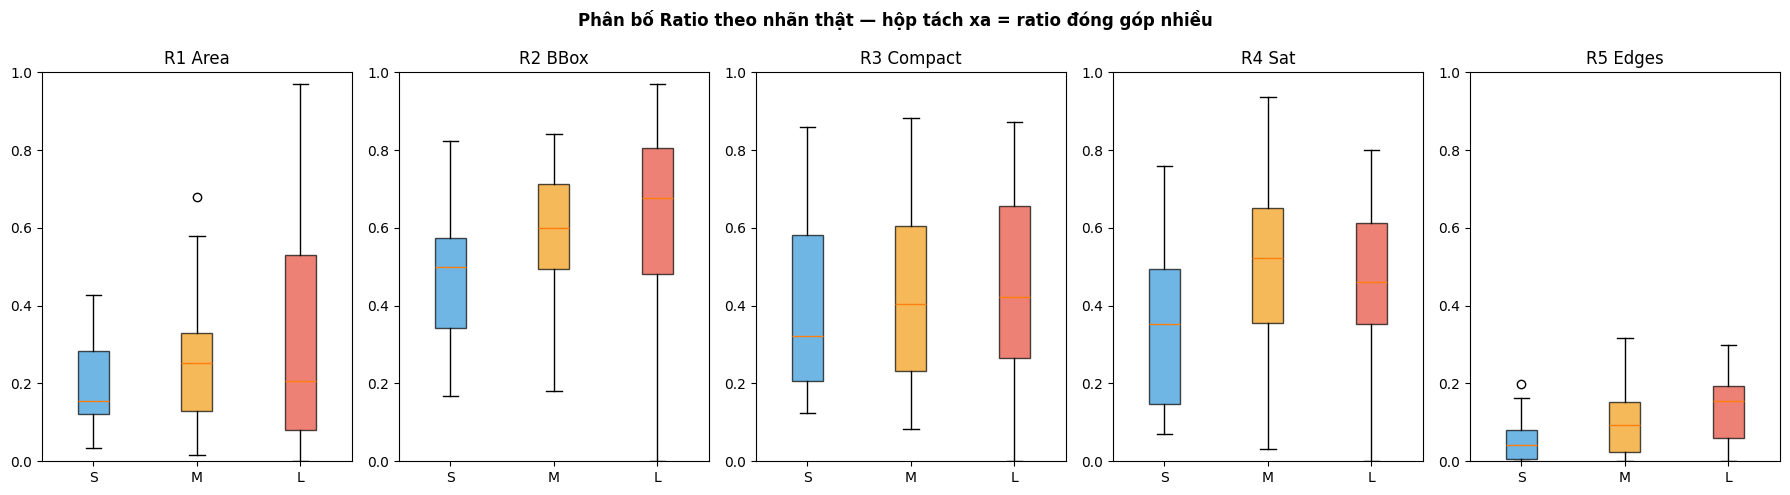

→ Ratio tách tốt nhất: tăng WEIGHTS tương ứng để cải thiện accuracy

✓ Xong! Kết quả: /kaggle/working/portion_output


In [ ]:
# VISUALISATION — samples + ratio boxplot
def visualize_samples(df, n_per_portion=2):
    samples = pd.concat([
        df[df['portion_label']==p].sample(
            min(n_per_portion, len(df[df['portion_label']==p])),
            random_state=SEED)
        for p in ['Small','Medium','Large']
    ]).reset_index(drop=True)

    n = len(samples)
    fig, axes = plt.subplots(n, 4, figsize=(17, 4*n))
    if n==1: axes=[axes]

    for i, row in samples.iterrows():
        img = cv2.imread(row['path'])
        r   = run_pipeline(img, food_class_override=row['food_class'])

        vis = r['_pre'].copy()
        x1,y1,x2,y2 = [int(v) for v in r['yolo_bbox']]
        cv2.rectangle(vis,(x1,y1),(x2,y2),(0,255,0),3)
        axes[i][0].imshow(cv2.cvtColor(vis,cv2.COLOR_BGR2RGB))
        axes[i][0].set_title(f'{row["food_class"]}\nYOLO: {r["yolo_source"]}')
        axes[i][0].axis('off')

        axes[i][1].imshow(r['_mask_raw'], cmap='gray')
        axes[i][1].set_title('SAM raw'); axes[i][1].axis('off')

        ov = r['_pre'].copy()
        ov[r['_mask']==0]=(ov[r['_mask']==0]*0.25).astype(np.uint8)
        axes[i][2].imshow(cv2.cvtColor(ov,cv2.COLOR_BGR2RGB))
        axes[i][2].set_title(
            f'Cleaned mask\nArea: {r["R1_area_ratio"]:.2%}')
        axes[i][2].axis('off')

        names  = ['R1','R2','R3','R4','R5']
        values = [r['R1_area_ratio'],r['R2_bbox_fill'],
                  r['R3_compactness'],r['R4_saturation'],
                  r['R5_edge_density']]
        color  = COLOR_MAP[r['portion_label']]
        axes[i][3].barh(names, values, color=color, alpha=0.85)
        axes[i][3].set_xlim(0,1)
        axes[i][3].set_title(
            f'{r["portion_label"]}  score={r["weighted_score"]:.3f}')
        for t in THRESHOLDS.values():
            axes[i][3].axvline(t,color='gray',linestyle='--',alpha=0.5)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'portion_samples.png',
                dpi=150, bbox_inches='tight')
    plt.show()


def plot_ratio_boxplots(df):
    cols   = ['R1_area_ratio','R2_bbox_fill','R3_compactness',
              'R4_saturation','R5_edge_density']
    labels = ['R1 Area','R2 BBox','R3 Compact','R4 Sat','R5 Edges']
    fig, axes = plt.subplots(1, 5, figsize=(18, 5))
    for ax, col, lbl in zip(axes, cols, labels):
        data = [df[df['manual_label']==p][col].dropna().values
                for p in ['Small','Medium','Large']]
        bp   = ax.boxplot(data, labels=['S','M','L'], patch_artist=True)
        for patch, c in zip(bp['boxes'],
                            [COLOR_MAP['Small'],COLOR_MAP['Medium'],
                             COLOR_MAP['Large']]):
            patch.set_facecolor(c); patch.set_alpha(0.7)
        ax.set_title(lbl); ax.set_ylim(0,1)
    fig.suptitle('Phân bố Ratio theo nhãn thật — '
                 'hộp tách xa = ratio đóng góp nhiều',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'ratio_boxplots.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('→ Ratio tách tốt nhất: tăng WEIGHTS tương ứng để cải thiện accuracy')


visualize_samples(df_labeled, n_per_portion=2)
plot_ratio_boxplots(df_labeled)
print(f'\n✓ Xong! Kết quả: {OUTPUT_DIR}')